Goal - Analyze waveform to find narrow and wide spiking cells 

In [16]:
#Importing Important Stuff
import os
import cv2
import sys
import math
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import scipy.interpolate
import scipy.signal
import sklearn.cluster
import fmEphys as fme
import pickle



In [2]:
#DOI
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2022\112322\G6CK7GLN',
                  r'D:\022223\J629LN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\053123\G6CK8hLN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\080123\G6Ck9DTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'H:\101724\G6CK10JRT',
                  r'H:\111524\J715RT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']





In [31]:
##Saline 
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\052124\J691RT',
                   r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']


In [2]:
#Rev Checker Dataset
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'H:\101724\G6CK10JRT',
                  r'H:\102624\J722LT',
                  r'H:\111524\J715RT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']

In [22]:
#Depth Analysis Dataset
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2022\112322\G6CK7GLN',
                  r'D:\022223\J629LN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\053123\G6CK8hLN',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\080123\G6Ck9DTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']


In [7]:
#FM DOI 
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\091223\G6CK9GRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\092223\G6CK9GTT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  #r'H:\101724\G6CK10JRT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT']

In [4]:
#Grating Dataset

RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2023\110723\J683LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\012324\G6CK11BTT',
                  r'\\goeppert\Vol2\Rolf\Freely Moving Ephys\2024\022024\G6CK10DTT',
                  r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                  r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT',
                  r'\\goeppert\Vol2\Rolf\Freely Moving Ephys\2025\013125\G6CK14BLN',
                  r'\\goeppert\Vol2\Rolf\Freely Moving Ephys\2025\021225']
                   

In [17]:
#Sparse noise datasets - DOI
RecordingsToUse = [r'D:\072624\J708LT',
                  r'D:\080224\J705RT',
                  r'D:\081024\J720LT',
                   r'H:\101724\G6CK10JRT',
                   r'H:\102624\J722LT',
                   r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\122024\J728LT',
                   r'\\goeppert\Vol2\Rolf\Freely Moving Ephys\2025\013125\G6CK14BLN']


In [26]:
#Sparse noise datasets - Saline
RecordingsToUse = [r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']

In [27]:
figs_on = 1

NoMatch = []
zz = 0
iiii = 0
ii = 0
for RecordingPath in RecordingsToUse:
    
    #Finding Single Unit .npy file for each recording
    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
            SU_File = (RecordingPath +'/' + Items)
    
    #Finding KS Cluster_info.tsv file for each recording
    for Items in os.listdir(RecordingPath):
        if Items.endswith("cluster_info.tsv"):
            Cluster_Info = (RecordingPath +'/' + Items)

    #Finding KS template.npy file for each recording
    for Items in os.listdir(RecordingPath):
        if Items.endswith("templates.npy"):
            Templates = (RecordingPath +'/' + Items)

    if ii < 7:
        #Finding FM1 Ephys data to get waveforms
        PreFM_Path = RecordingPath + '/fm1'
        for Items in os.listdir(PreFM_Path):
            if Items.endswith("ephys_props.h5"):
                EphysFile = (PreFM_Path + '/' + Items)
    elif ii >= 7:
        #Finding FM1 Ephys data to get waveforms
        PreFM_Path = RecordingPath + '/fm2'
        for Items in os.listdir(PreFM_Path):
            if Items.endswith("ephys_props.h5"):
                EphysFile = (PreFM_Path + '/' + Items)
                
    date = os.path.basename(os.path.dirname(RecordingPath))
    mouse = os.path.basename(RecordingPath)
    DateAndMouse = date + '_' + mouse

    #Loading Data files
    MouseSUs = np.load(SU_File)
    MouseData = pd.read_hdf(EphysFile)
    Mouse_Template = np.load(Templates)   #Cells, time, probe channel
    Mouse_Cluster_Info = pd.read_csv(Cluster_Info, sep = '\t',index_col=0)

    #MouseData = MouseData.loc[MouseSUs]
    try:
        nSpikes_FromPipeline = MouseData.loc[MouseSUs,'FmLt_n_spikes']
    except:
        nSpikes_FromPipeline = MouseData.loc[MouseSUs,'FmDk_n_spikes']
        
    nSpikes_FromKS = Mouse_Cluster_Info.loc[:,'n_spikes']
    #ContamPct_FromPipeline = MouseData.loc[:,'FmLt_ContamPct']
    #ContamPct_FromKS = Mouse_Cluster_Info.loc[:,'ContamPct']
 #   try:    
 #       waves_indMice = np.stack(MouseData.loc[:,'FmLt_waveform'])
 #   except:
 #       waves_indMice = np.stack(MouseData.loc[:,'FmDk_waveform'])
 #    waves_all = np.concatenate((waves_all,waves_indMice),axis=0)

 # Due to use of KS4 the waveforms in the MouseData file are not correct. 
 # To find the correct waveform (because channel location is not correct either)
    try:
        Ch_test = MouseData.loc[:,'FmLt_ch']
    except:
        Ch_test = MouseData.loc[:,'FmDk_ch']



    All_Waves_temp = np.zeros([len(nSpikes_FromPipeline.index),82])

    for ii in range(0,len(nSpikes_FromPipeline.index)):
        try:
            Row  = int(np.squeeze(np.where((nSpikes_FromKS == nSpikes_FromPipeline[nSpikes_FromPipeline.index[ii]]))))
        except TypeError:
            NoMatch.append({'Mouse': DateAndMouse,
                            'Cell': nSpikes_FromPipeline.index[ii]})

            Row = int(Ch_test[nSpikes_FromPipeline.index[ii]])
            
        finally:

            if np.shape(Mouse_Template[Row,:,:])[0] < 80:
                Wave = Mouse_Template[Row,:,np.argmin(np.min(Mouse_Template[Row,18:22,:],axis=0))]
            #Wave = Mouse_Template[Row,:,np.argmax(np.var(Mouse_Template[Row,:,:],axis=0))]
            #Wave2 = Mouse_Template[Row,:,np.argmax(np.sum(np.abs(Mouse_Template[Row,:,:]),axis=0))]
            else:
                Wave = Mouse_Template[Row,:,np.argmin(np.min(Mouse_Template[Row,38:42,:],axis=0))]

            if len(Wave) < 80:
                Remainder = 82 - len(Wave)
                All_Waves_temp[ii,Remainder:] = Wave
            else:
                All_Waves_temp[ii,:] = Wave

            if figs_on == 1:
                plt.figure(figsize=(10,10))
                plt.plot(Mouse_Template[Row,:,:],color = 'black')
                plt.plot(Wave,color = 'blue')
                plt.savefig('D:\PrePostDOI\Single Unit Plots\SN Data\Saline\SU_' +  str(iiii) + '_Mouse' + str(DateAndMouse) + 'Cell ' + str(nSpikes_FromPipeline.index[ii]) + '.png', bbox_inches='tight')
                plt.close()
        iiii = iiii + 1

    if zz == 0:
        All_Waves = All_Waves_temp
        zz = 1
    else:
        All_Waves = np.concatenate((All_Waves,All_Waves_temp))

    ii = ii + 1 

In [33]:
#Looked through the plots for each cell in D:\PrePostDOI\Single Unit Plots to find not real SUs and added them to the list below for removal

##DOI Removers
#ToRemove =  [0,9,24,48,49,51,52,53,66,69,79,80,81,88,99,100,125,157,158,170,173,184,224,236,238,255,256,257,269,273,283,284,299,310,318,330,334,391,392,393,394,395,396,405,406,407,408,409,410,411,412,413,427,428,435,474,476,686,692,728,740,789,791,793,795,874,881,890,900,901,902,915,921,926,956,957]

##Saline Removers
#ToRemove = [40,47,68,71,134,136,138,229,234,246,262]

##RC Removers
#ToRemove = [3,4,21,31,32,33,47,58,66,78,92,139,140,141,142,143,144,153,154,155,156,157,158,159,175,176,183,434,440,476,484,537,539,541,633,636,670,677,686,696,697,698,722,752,753]

##Depth Dataset
#ToRemove =  [0,9,24,48,49,51,52,53,66,69,79,80,81,88,99,100,125,157,158,170,173,184,224,236,238,255,256,257,269,273,283,284,299,310,318,330,334,391,392,393,394,395,396,405,406,407,408,409,410,411,412,413,427,428,435,474,476,686,692,728,740,789,791,793,795]

##FM DOI Dataset
#ToRemove = [9,12,22,23,24,31,39,42,43,68,100,101,107,112,113,116,127,130,135,167,179,181,182,198,199,200,208,212,214,215,216,218,226,227,228,237,241,242,244,253,255,261,262,276,279,280,281,286,297,314,323,330,332,333,334,335,336,337,338,339,341,342,343,345,346,347,348,349,350,351,352,353,355,356,367,368,375,390,414,416,540,545,626,632,668,680,697,704,713,716,723,724,725,726,737,738,744,747,749,779,780]

##DG DOI Dataset
#ToRemove = [3,4,5,17,21,23,31,32,33,46,47,49,53,54,58,66,78,91,128,135,137,138,139,140,141,150,151,52,153,154,155,156,157,158,172,173,180,195,216,219,221,350,431,437,473,485,502,509,518,528,529,530,531,533,542,543,544,546,549,554,584,585,588,590,595,597,599,607,609,612,613,614,615,616]

## SN DOI Dataset
#ToRemove = [32,35,37,44,166,170,221,247,253,289,301,338,349,350,352,355,357,384,385,395,398,409,429,430,442,445,458,465,473,474,484,485,486,487,489,498,499,505,508,510,532,537,540,541,544,551,552,553,563,565]

##SN Saline Dataset
ToRemove = [21,28,48,68,115,117,119,209,210,215,227,243]

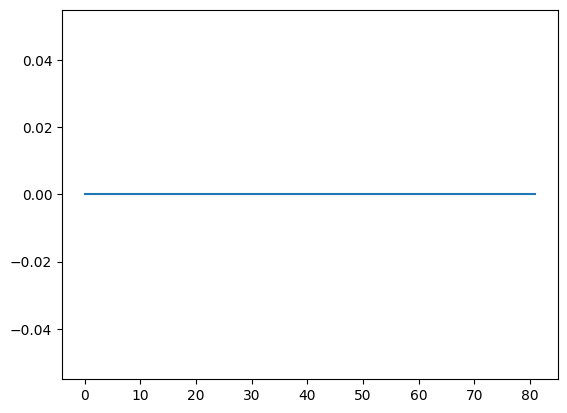

In [32]:
plt.plot(All_Waves_Limited[ii])

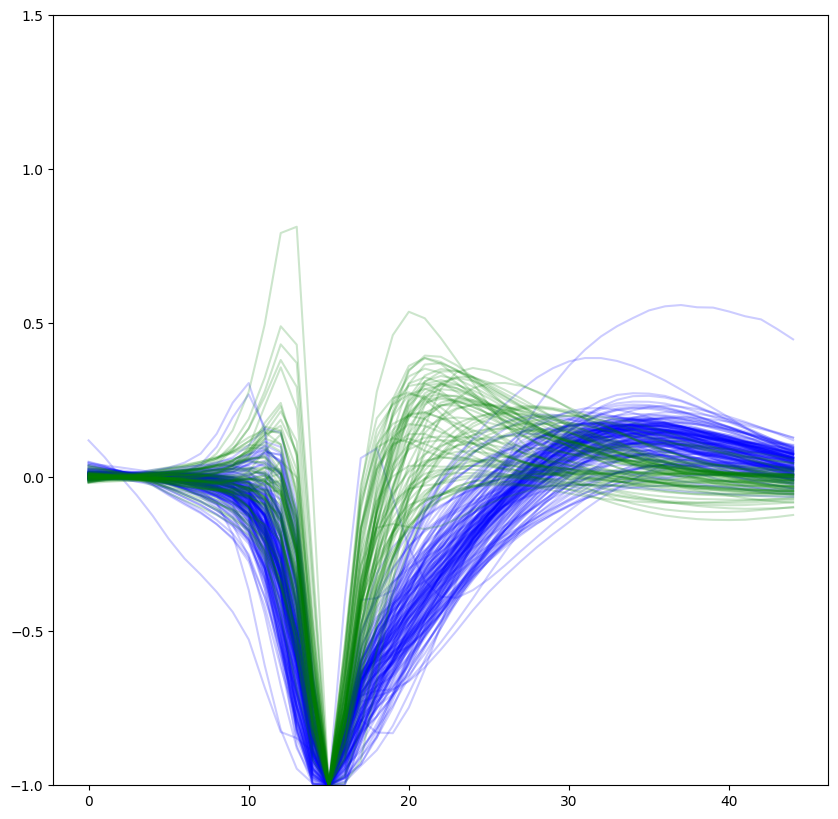

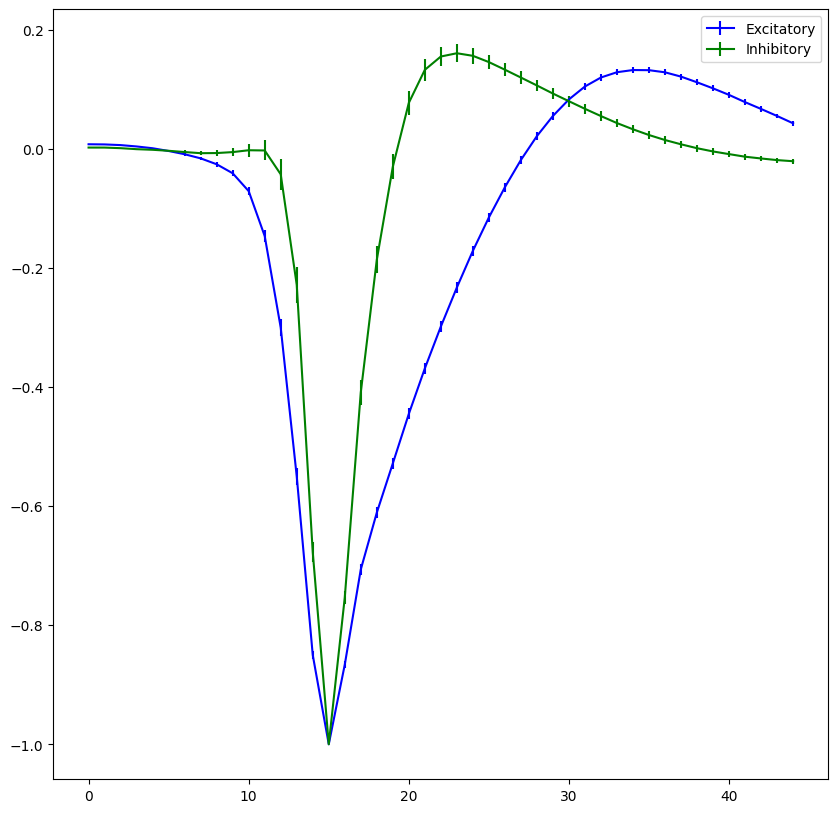

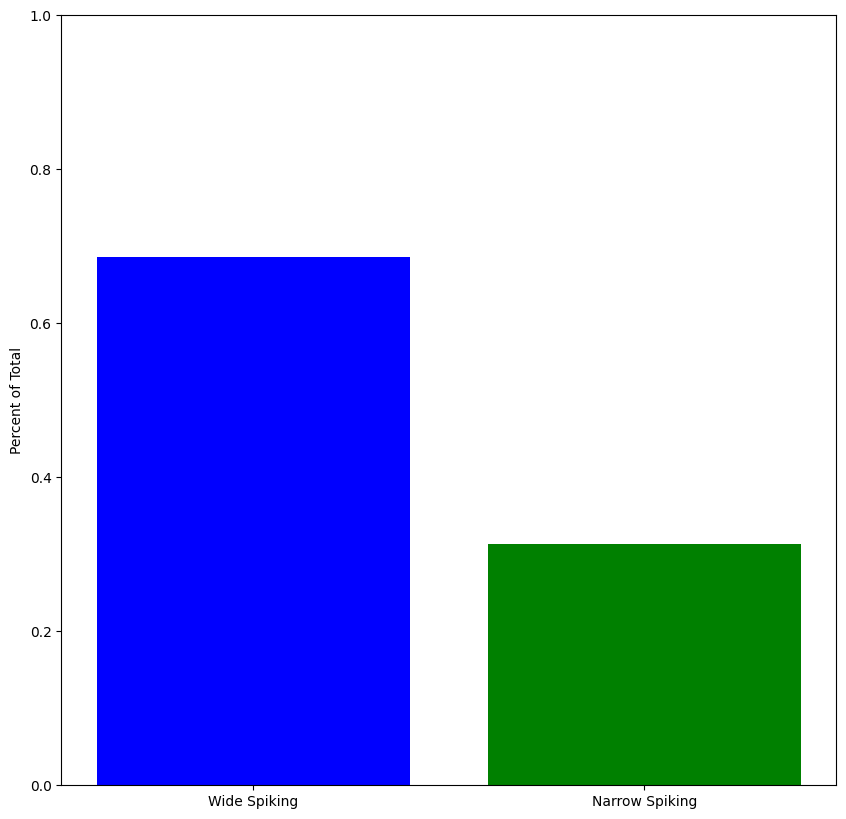

In [35]:

figs_on = 1 #1 to plot figures 

#Dropping fake SUs from FullDataset
FullDataset = pd.read_hdf(r"D:\PrePostDOI\Saline Datasets\SNandWNMice_GazeShifts_Saline.h5")
FullDataset = FullDataset.drop((ToRemove))

All_Waves_Limited = np.zeros((np.shape(FullDataset)[0],82))

#Removing not real waveforms
tt = 0
for ii in range(0,len(All_Waves)):
    if ii in ToRemove:
        zz = 0
    else:
        All_Waves_Limited[tt,:] = All_Waves[ii,:] 
        tt = tt +1

#All_Waves_Limited = All_Waves.copy()

#Normalizing Waveforms
All_Waves_Limited = All_Waves_Limited - np.nanmean(All_Waves_Limited[:,21:35], axis=1)[:,None]
All_Waves_Short = np.zeros([len(All_Waves_Limited),45])

for ii in range(0, len(All_Waves_Limited)):
    Min_Idx = np.argmin(All_Waves_Limited[ii])
    
    All_Waves_Short[ii,:] = All_Waves_Limited[ii,Min_Idx-15:Min_Idx+30]
    
        

All_Waves_Norm = All_Waves_Short/-All_Waves_Short[:,15][:,None]

#Using K means to cluster waveforms into two groups
km = sklearn.cluster.KMeans(n_clusters=2)
km.fit(All_Waves_Norm)
km_labels = km.labels_

if figs_on == 1:
    #Plotting All waveforms by km cluster label
    plt.figure(figsize=(10,10))
    plt.plot(All_Waves_Norm[km_labels==0,:].T,color = 'blue',alpha = .2,label = 'Excitatory')
    plt.plot(All_Waves_Norm[km_labels==1,:].T,color = 'green',alpha = .2,label = 'Inhibitory')
    plt.ylim(-1 , 1.5)
    

    #Plotting average waveforms by km cluster label
    plt.figure(figsize=(10,10))
    plt.errorbar(np.arange(0,45,1),y=np.nanmean(All_Waves_Norm[km_labels==0,:],axis=0),yerr=np.std(All_Waves_Norm[km_labels==0,:],axis=0)/np.sqrt(len(All_Waves_Norm[km_labels==0,:])),color = 'blue',label = 'Excitatory')
    plt.errorbar(np.arange(0,45,1),np.nanmean(All_Waves_Norm[km_labels==1,:],axis=0),yerr=np.std(All_Waves_Norm[km_labels==1,:],axis=0)/np.sqrt(len(All_Waves_Norm[km_labels==1,:])),color = 'green',label = 'Inhibitory')
    plt.legend()

    #Plotting percentage of population for each cluster
    plt.figure(figsize=(10,10))
    plt.bar(1,sum(km_labels== 0)/len(km_labels),color = 'blue')
    plt.bar(2,sum(km_labels== 1)/len(km_labels),color = 'green' )
    plt.ylim(0,1)
    plt.ylabel('Percent of Total')
    plt.xticks([1,2],['Wide Spiking','Narrow Spiking'])

FullDataset['Waveform'] = All_Waves_Norm.tolist()
FullDataset['Waveform_Cluster'] = km_labels.tolist()

FullDataset.to_hdf(r"D:\PrePostDOI\Saline Datasets\SNandWNMice_GazeShifts_Saline.h5", 'w')

In [21]:
np.shape(All_Waves_Limited)

(264, 82)

Text(0, 0.5, 'Depth')

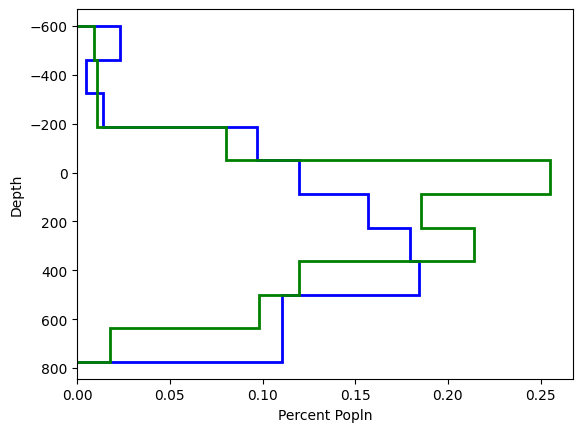

In [47]:
FullDataset.columns
Depth = np.stack(FullDataset.loc[:,'Depth_from_L5'])
Waveform_Cluster = np.stack(FullDataset.loc[:,'Waveform_Cluster'])

NS = np.argwhere(Waveform_Cluster == 0)
WS = np.argwhere(Waveform_Cluster == 1)

NS_Weights = np.ones(len(NS))/len(NS)
WS_Weights = np.ones(len(WS))/len(WS)
plt.hist(Depth[NS],histtype='step',color = 'blue',weights=NS_Weights,orientation='horizontal',linewidth=2)
plt.hist(Depth[WS],histtype='step',color = 'green',weights=WS_Weights,orientation='horizontal',linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel('Percent Popln')
plt.ylabel('Depth')
